### Create SMET Forcing Files from Met Station Data (filled with HRRR-AK): Point Simulation Heen Latinee SNOTEL (HEEN)

Notebook contents 
* SNOWPACK takes an SMET file, so let's create that for point simulations

created by Cassie Lumbrazo\
last updated: May 2026\
run location: UAS linux\
python environment: **rasterio**

In [1]:
# import packages 
%matplotlib inline

# plotting packages 
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns 

sns.set_theme()
plt.rcParams['figure.figsize'] = [12,6] #overriding size

# data packages 
import pandas as pd
import numpy as np
import xarray as xr
from datetime import datetime

import scipy

import rioxarray
import rasterio 
import cfgrib
import os

import geopandas as gpd

from zoneinfo import ZoneInfo
from pathlib import Path

In [2]:
pwd

'/home/cassie/python/repos/snow_modeling_point/sites/heen'

## Load Heen SNOTEL Data: Cleaned in `1_clean_met_heen.ipynb`

In [3]:
# open observations
# file_heen = "/hdd/snow_hydrology/met_station/snotel/heenlatinee/site1270_hourly_2016_2026.nc"
file_heen_clean_cut = "/hdd/snow_hydrology/met_station/snotel/heenlatinee/heen_met_2018_2022_cleaned_v1.nc"
ds_met = xr.open_dataset(file_heen_clean_cut)

# cut the datetime to be from 2024 10 01 to 2025 09 30 to match the snowpack output
ds_met = ds_met.sel(time=slice("2019-10-01T05:00:00", "2022-09-30T05:00:00"))
ds_met


<xarray.Dataset> Size: 2MB
Dimensions:           (time: 23483)
Coordinates:
  * time              (time) datetime64[ns] 188kB 2019-10-01T05:00:00 ... 202...
Data variables:
    swe               (time) float64 188kB ...
    temp              (time) float64 188kB ...
    hs                (time) float64 188kB ...
    rh                (time) float64 188kB ...
    precip_accum      (time) float64 188kB ...
    wind              (time) float64 188kB ...
    wind_dir          (time) float64 188kB ...
    pressure          (time) float64 188kB ...
    precip_rate       (time) float64 188kB ...
    precip_accum_1hr  (time) float64 188kB ...

In [4]:
# print the first few timesteps of the ds 
ds_met.time.values[:10]

array(['2019-10-01T05:00:00.000000000', '2019-10-01T06:00:00.000000000',
       '2019-10-01T07:00:00.000000000', '2019-10-01T08:00:00.000000000',
       '2019-10-01T09:00:00.000000000', '2019-10-01T10:00:00.000000000',
       '2019-10-01T11:00:00.000000000', '2019-10-01T12:00:00.000000000',
       '2019-10-01T13:00:00.000000000', '2019-10-01T14:00:00.000000000'],
      dtype='datetime64[ns]')

In [5]:
# # plot all the variables to see what we have and how they look
# for var in ds_met.data_vars:
#     plt.figure()
#     ds_met[var].plot()
#     plt.title(f"{var} Time Series at HEEN SNOTEL WY2021")
#     plt.xlabel("Time")
#     plt.ylabel(f"{var} ({ds_met[var].attrs.get('units', '')})")
#     plt.grid(True, alpha=0.3)
#     plt.show()
    

We should not need much cleaning here since we did it largely in script 1...

_________________________________________________________________

## Load the HRRR-AK Dataset

In [6]:
# input_file = "/hdd/snow_hydrology/hrrrak/large_juneau_domain/netcdf/hrrrak_f567_WY2025_utm_site_heen.nc"
input_file = "/hdd/snow_hydrology/hrrrak/icefield_domain/netcdf/hrrrak_f567_WY2020-WY2025_utm_site_heen.nc"
ds_hrrr = xr.open_dataset(input_file)
ds_hrrr.rio.write_crs("EPSG:32608", inplace=True) # we know it is in UTM from the previous script work

# and clip to WY2020,2021,2022 
ds_hrrr = ds_hrrr.sel(time=slice("2019-10-01T05:00:00", "2022-09-30T05:00:00"))
ds_hrrr

<xarray.Dataset> Size: 7MB
Dimensions:       (time: 26281)
Coordinates:
    valid_time    (time) datetime64[ns] 210kB ...
    step          (time) timedelta64[ns] 210kB ...
  * time          (time) datetime64[ns] 210kB 2019-10-01T05:00:00 ... 2022-09...
    y             float64 8B ...
    x             float64 8B ...
    spatial_ref   int64 8B 0
Data variables: (12/28)
    gust          (time) float64 210kB ...
    pressure      (time) float64 210kB ...
    orog          (time) float64 210kB ...
    temp_surface  (time) float64 210kB ...
    swe           (time) float64 210kB ...
    snowdepth     (time) float64 210kB ...
    ...            ...
    suswrf        (time) float64 210kB ...
    sulwrf        (time) float64 210kB ...
    wind          (time) float64 210kB ...
    wind_dir      (time) float64 210kB ...
    veg           (time) float64 210kB ...
    lai           (time) float64 210kB ...
Attributes: (12/13)
    long_name:       Wind speed (gust)
    units:           m s**-1
    GRIB_shortName:  gust
    GRIB_name:       Wind speed (gust)
    GRIB_cfName:     unknown
    GRIB_cfVarName:  gust
    ...              ...
    typeOfLevel:     surface
    site_name:       heen
    original_lat:    58.69652
    original_lon:    -134.86448
    utm_x:           507854.334991801
    utm_y:           6506268.082489309

In [7]:
# print the first few timesteps of the ds 
ds_hrrr.time.values[:10]

array(['2019-10-01T05:00:00.000000000', '2019-10-01T06:00:00.000000000',
       '2019-10-01T07:00:00.000000000', '2019-10-01T08:00:00.000000000',
       '2019-10-01T09:00:00.000000000', '2019-10-01T10:00:00.000000000',
       '2019-10-01T11:00:00.000000000', '2019-10-01T12:00:00.000000000',
       '2019-10-01T13:00:00.000000000', '2019-10-01T14:00:00.000000000'],
      dtype='datetime64[ns]')

In [8]:
# check that both datasets have the same time range and frequency
print("HEEN SNOTEL Met Dataset:")
print(f"Start: {ds_met.time.values[0]}, End: {ds_met.time.values[-1]}, Frequency: {pd.infer_freq(ds_met.time.values)}")
print("\nHRRR AK Dataset:")
print(f"Start: {ds_hrrr.time.values[0]}, End: {ds_hrrr.time.values[-1]}, Frequency: {pd.infer_freq(ds_hrrr.time.values)}")

HEEN SNOTEL Met Dataset:
Start: 2019-10-01T05:00:00.000000000, End: 2022-09-30T05:00:00.000000000, Frequency: None

HRRR AK Dataset:
Start: 2019-10-01T05:00:00.000000000, End: 2022-09-30T05:00:00.000000000, Frequency: h


In [9]:
# Create continuous hourly time axis
ds_met = (ds_met.resample(time='1h').asfreq())

In [10]:
# check that both datasets have the same time range and frequency
print("HEEN SNOTEL Met Dataset:")
print(f"Start: {ds_met.time.values[0]}, End: {ds_met.time.values[-1]}, Frequency: {pd.infer_freq(ds_met.time.values)}")
print("\nHRRR AK Dataset:")
print(f"Start: {ds_hrrr.time.values[0]}, End: {ds_hrrr.time.values[-1]}, Frequency: {pd.infer_freq(ds_hrrr.time.values)}")

HEEN SNOTEL Met Dataset:
Start: 2019-10-01T05:00:00.000000000, End: 2022-09-30T05:00:00.000000000, Frequency: h

HRRR AK Dataset:
Start: 2019-10-01T05:00:00.000000000, End: 2022-09-30T05:00:00.000000000, Frequency: h


Compare Precipiation, 

In [11]:
ds_hrrr['precip_accum_1hr'] = ds_hrrr['precip_rate'] * 3600 # convert from mm/s to mm/hr for comparison with the observed data

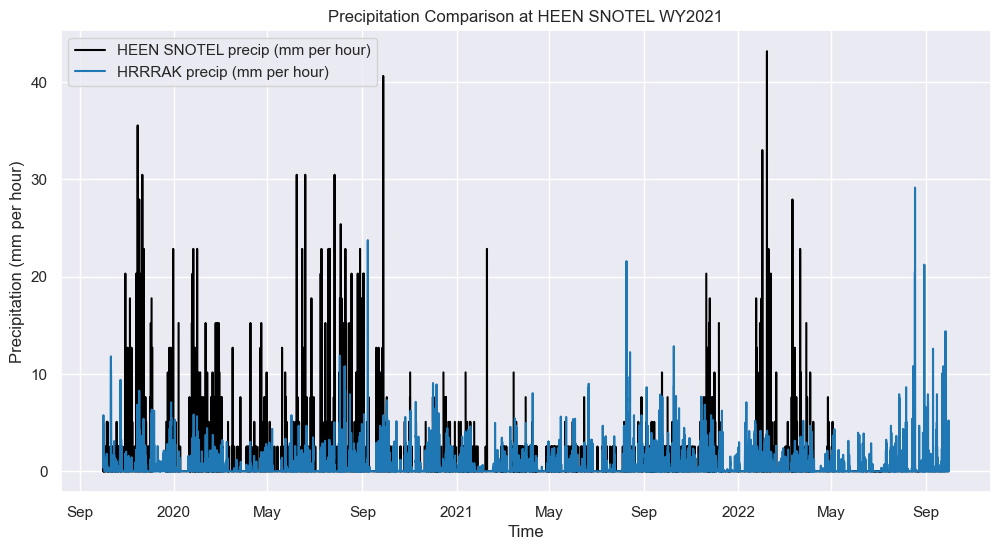

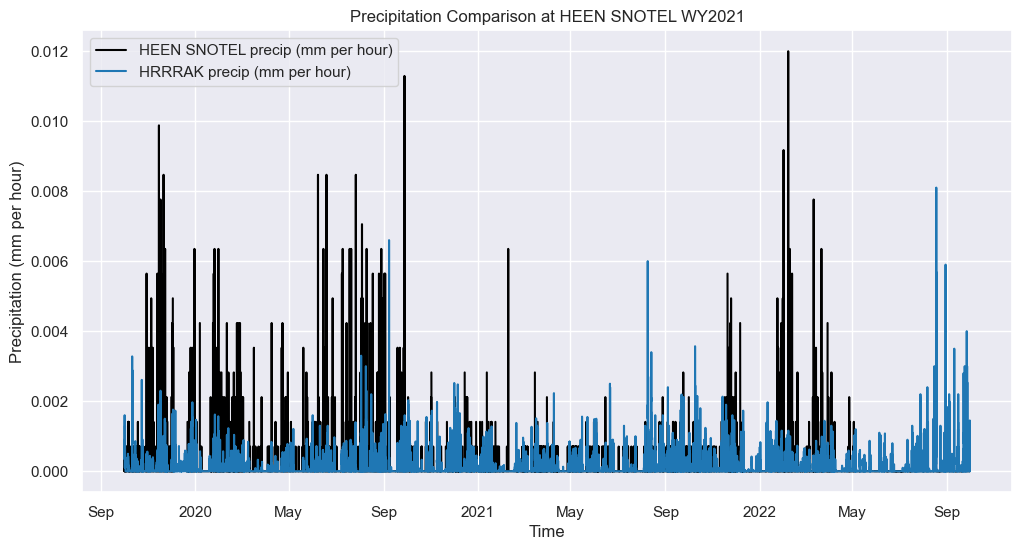

In [12]:
# compare precip 
ds_met["precip_accum_1hr"].plot(label="HEEN SNOTEL precip (mm per hour)", color='black')
ds_hrrr['precip_accum_1hr'].plot(label="HRRRAK precip (mm per hour)", color='tab:blue')
plt.title("Precipitation Comparison at HEEN SNOTEL WY2021")
plt.xlabel("Time")
plt.ylabel("Precipitation (mm per hour)")
plt.legend()
plt.show()

# compare precip 
ds_met["precip_rate"].plot(label="HEEN SNOTEL precip (mm per hour)", color='black')
ds_hrrr['precip_rate'].plot(label="HRRRAK precip (mm per hour)", color='tab:blue')
plt.title("Precipitation Comparison at HEEN SNOTEL WY2021")
plt.xlabel("Time")
plt.ylabel("Precipitation (mm per hour)")
plt.legend()
plt.show()

Compare accumulated precip, 

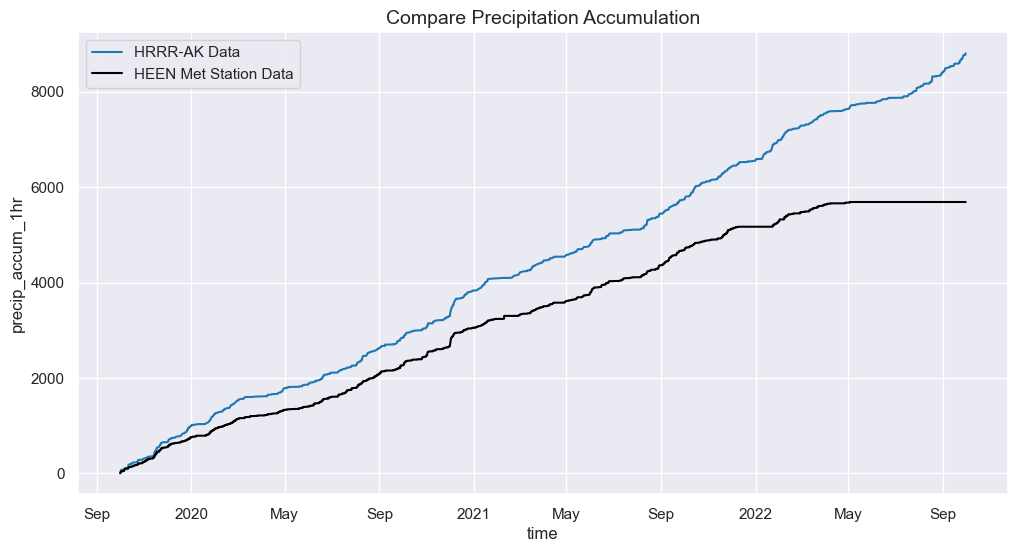

In [13]:
ds_hrrr['precip_accum_1hr'].cumsum().plot(label='HRRR-AK Data', color='tab:blue')

# now divide precip accum by 2 to compare 
# (ds_hrrr['precip_accum_1hr'].cumsum() / 1.3).plot(label='HRRR-AK Data Scale (Divide) by 1.3', color='tab:orange')
ds_met['precip_accum_1hr'].cumsum().plot(label='HEEN Met Station Data', color='black')

plt.title('Compare Precipitation Accumulation', fontsize=14)
plt.legend()
plt.show()

Air temperature, 

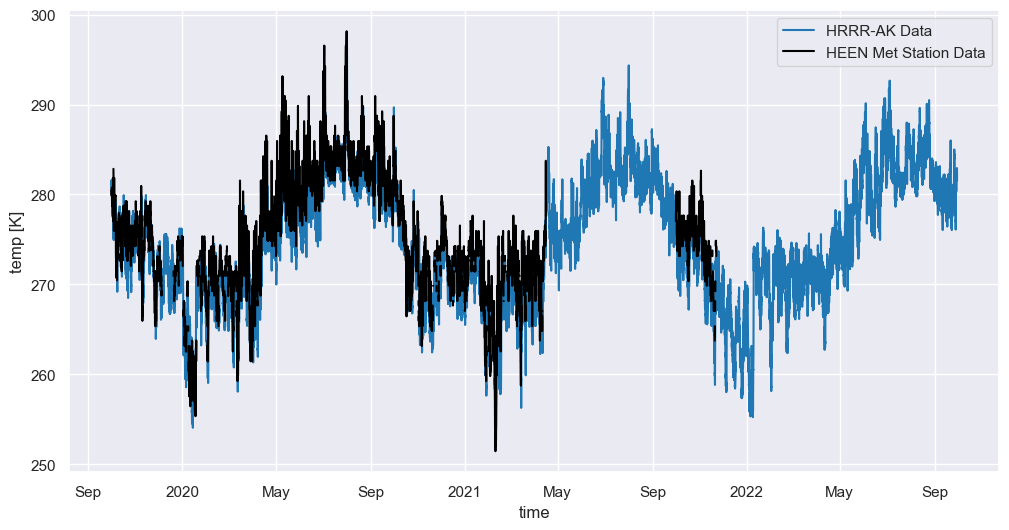

In [14]:
# compare temp
ds_hrrr.temp.plot(label='HRRR-AK Data', color='tab:blue')
ds_met.temp.plot(label='HEEN Met Station Data', color='black')

plt.legend()

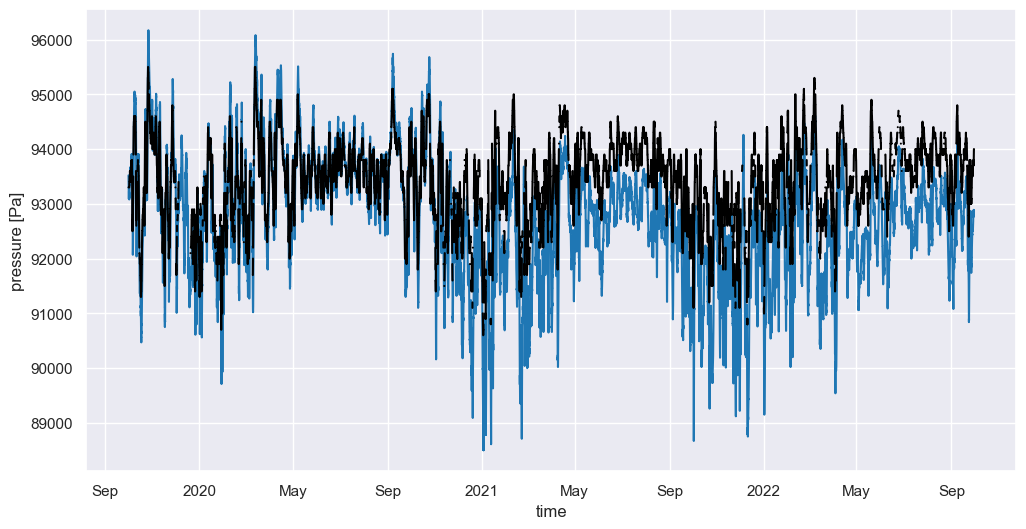

In [15]:
# compare pressure
ds_hrrr['pressure'].plot(label='HRRR-AK Data', color='tab:blue')
ds_met['pressure'].plot(label='HEEN Met Station Data', color='black')

Relative Humidity, 

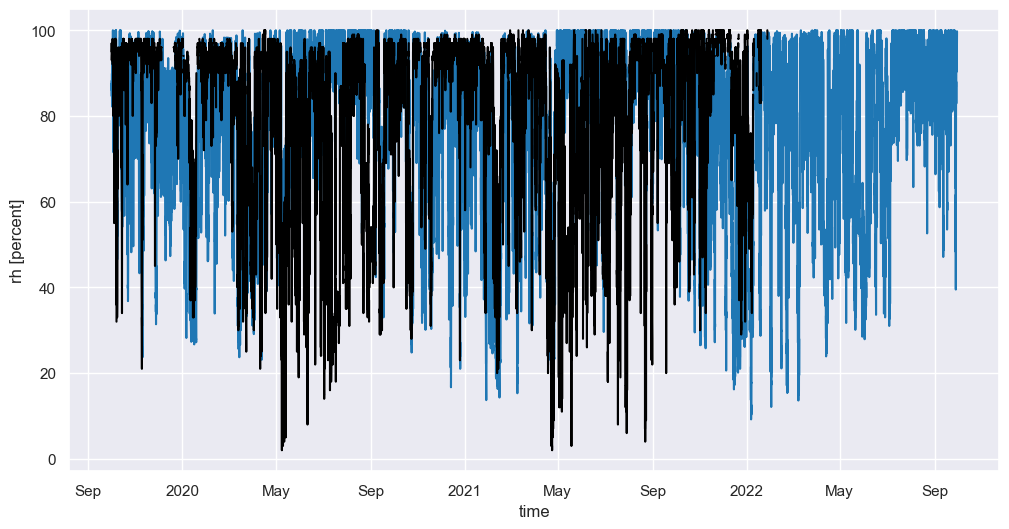

In [16]:
# compare rh 
ds_hrrr['rh'].plot(label='HRRR-AK Data', color='tab:blue')
ds_met['rh'].plot(label='HEEN Met Station Data', color='black')

Wind speed, 

Text(0, 0.5, 'Wind Speed (m/s)')

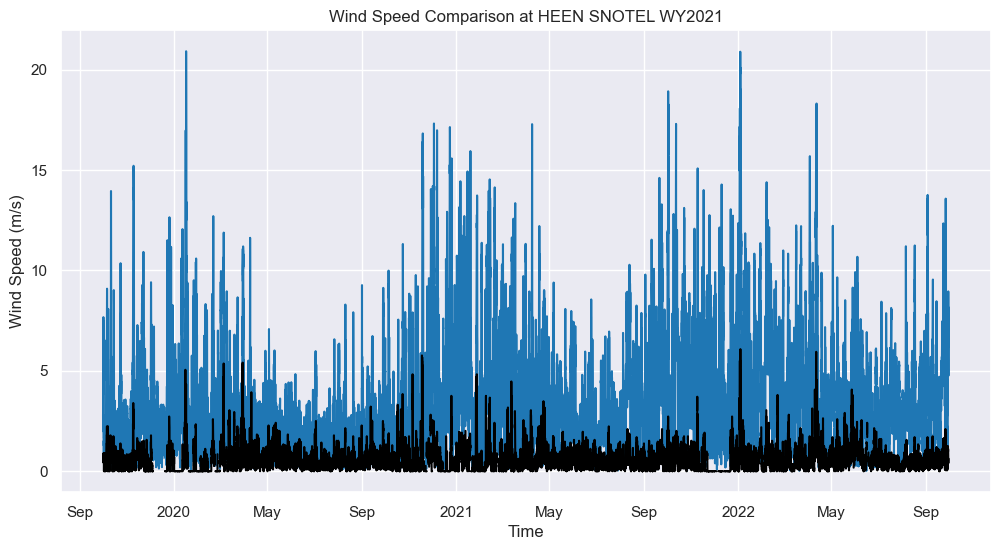

In [17]:
# compare wind speed 
ds_hrrr['wind'].plot(label="HRRRAK wind speed (m/s)", color='tab:blue')
ds_met['wind'].plot(label="HEEN SNOTEL wind speed (m/s)", color='black') # this should be converted to m/s
plt.title("Wind Speed Comparison at HEEN SNOTEL WY2021")
plt.xlabel("Time")
plt.ylabel("Wind Speed (m/s)")

We are not going to use wind speed or direction from this station since we know the sesnor is a RMYoung5103 and it gets rimed up very easily. The wind speeds seem exceptonally low for this site, so we will use HRRR.

Wind direction, 

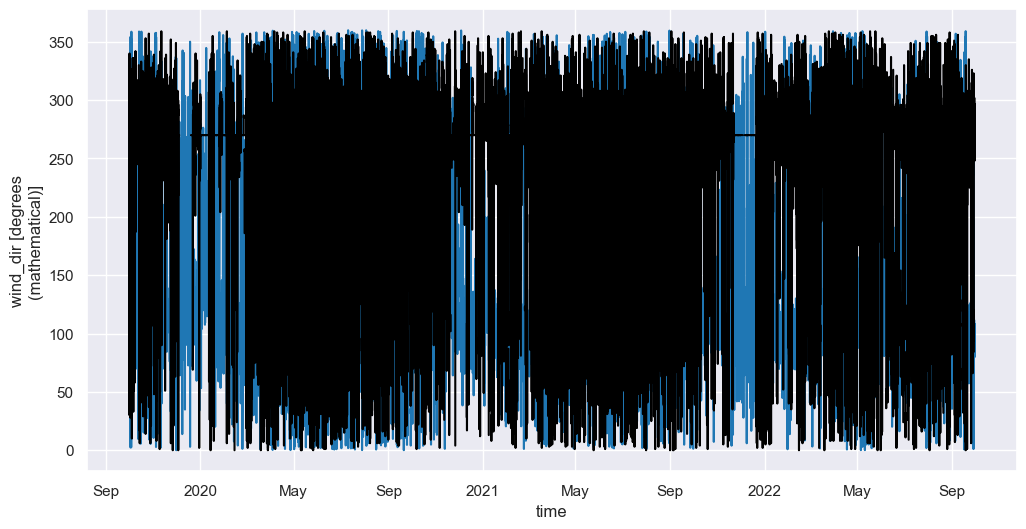

In [18]:
# comapre wind direction 
ds_hrrr['wind_dir'].plot(label="HRRRAK wind direction (degrees)", color='tab:blue')
ds_met['wind_dir'].plot(label="HEEN SNOTEL wind direction (degrees)", color='black') # this should be converted to degrees meteorological

In [19]:
# print the first few timestamps to see the time resolution
print(ds_hrrr.time.values[:10])

['2019-10-01T05:00:00.000000000' '2019-10-01T06:00:00.000000000'
 '2019-10-01T07:00:00.000000000' '2019-10-01T08:00:00.000000000'
 '2019-10-01T09:00:00.000000000' '2019-10-01T10:00:00.000000000'
 '2019-10-01T11:00:00.000000000' '2019-10-01T12:00:00.000000000'
 '2019-10-01T13:00:00.000000000' '2019-10-01T14:00:00.000000000']


# The Workflow Below, 

HRRR (NetCDF / xarray)\
   → your Python script\
   → SMET (ASCII)\
   → SNOWPACK


#### MeteoIO Variable Names 
| MeteoIO name | Meaning                      | Required?            | Expected units              |
| ------------ | ---------------------------- | -------------------- | --------------------------- |
| `TA`         | Air temperature              | yes                  | °K                          |
| `RH`         | Relative humidity            | yes                  | fraction (0-1)              |
| `VW`         | Wind speed                   | yes                  | m s⁻¹                       |
| `DW`         | Wind direction               | optional             | degrees (0–360, from North) |
| `ISWR`       | Incoming shortwave radiation | strongly recommended | W m⁻²                       |
| `ILWR`       | Incoming longwave radiation  | strongly recommended | W m⁻²                       |
| `PSUM`       | Precipitation (increment)    | yes                  | mm (per timestep)           |
| `P`          | Air pressure                 | optional             | Pa                          |


HRRR to MeteIO Variable Mapping 

In [20]:
# --- Unit expectations (SMET / MeteoIO) ---
# TA    : Kelvin
# RH    : fraction (0–1)
# VW    : m s-1
# DW    : degrees (meteorological)
# ISWR : W m-2
# ILWR : W m-2
# PSUM : mm per timestep
# P     : Pa

# Create SMET File

In [21]:
from pathlib import Path
from pyproj import Transformer

In [22]:
# lat_ppsa2, lon_ppsa2, elevation_ppsa2 = 58.26200, -134.51700, 670
# lat_tram, lon_tram, elevation_tram = 58.2971, -134.386, 529
lat_heen, lon_heen, elevation_heen = 58.69652, -134.86448, 548
# lat_tkg4, lon_tkg4, elevation_tkg4 = 58.63447,-134.23708, 1120

In [23]:
# relate the variables, df_met is for the met station data 
ds_met = ds_met.copy()

# ds is for the HRRRAK data
ds_hrrrak = ds_hrrr.copy()


Original dataset ranges:
MET:  2019-10-01T05:00:00.000000000 -> 2022-09-30T05:00:00.000000000
HRRR: 2019-10-01T05:00:00.000000000 -> 2022-09-30T05:00:00.000000000

Coverage statistics:
MET precip valid fraction: 0.8934211026977664
HRRR precip valid fraction: 1.0
MET pressure valid fraction: 0.8925459457402687

Fraction of timesteps using MET data:
TA: 0.49199041132377
RH: 0.6745938130208136
PSUM: 0.8934211026977664
PS: 0.8925459457402687

Timesteps where PSUM differs from HRRR:
8520

PSUM source diagnostics:
MET PSUM timesteps used: 23480
HRRR PSUM fill timesteps: 2801
Missing final PSUM timesteps: 0
MET PSUM total: 5605.78
HRRR PSUM total: 8808.624000120162
Final mixed PSUM total: 6684.16

Pressure source diagnostics:
MET pressure timesteps used: 23457
HRRR pressure fill timesteps: 2824
Missing final PS timesteps: 0

SMET file written to:
/home/cassie/python/models/run_snowpack/sites/heen/input/met_hrrrak_heen_WY2020-WY2022.smet


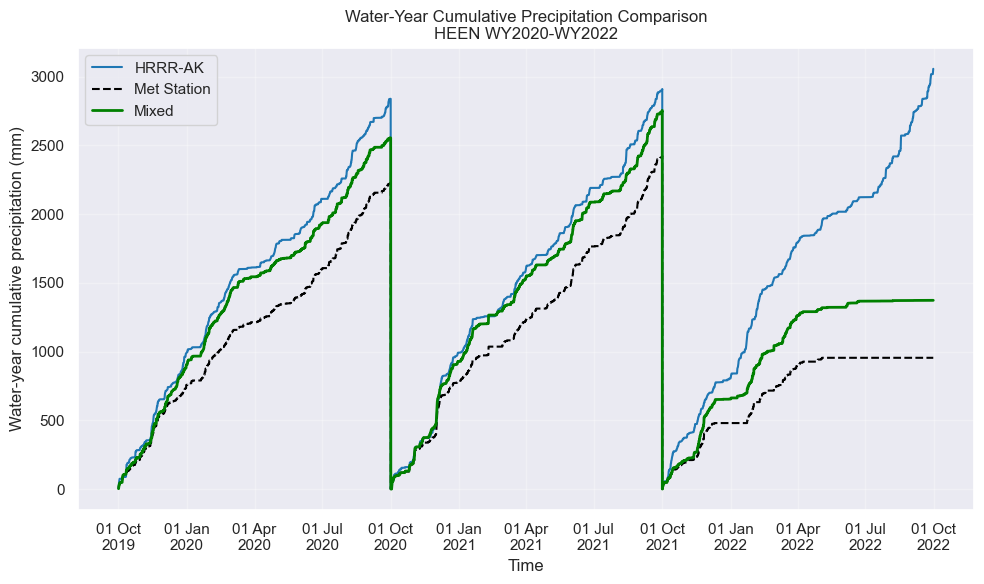

In [30]:
import xarray as xr
import pandas as pd
import numpy as np
from pathlib import Path
from pyproj import Transformer
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter

# ============================================================
# USER SETTINGS
# ============================================================

start_time = "2019-10-01T05:00"
end_time   = "2022-09-30T05:00"

TIMESTEP = "1h"

OUTFILE = Path(
    "/home/cassie/python/models/run_snowpack/sites/heen/input/"
    "met_hrrrak_heen_WY2020-WY2022.smet"
)

STATION_ID   = "met_hrrrak_heen_WY2020-WY2022"
STATION_NAME = "Met Station and HRRR-AK HEEN Point Forcing"

LAT  = lat_heen
LON  = lon_heen
ELEV = elevation_heen

EPSG   = 32608
TZ     = 0
NODATA = -999

# ============================================================
# SLICE TO COMMON TIME RANGE
# ============================================================

ds_met = ds_met.sel(time=slice(start_time, end_time))
ds_hrrrak = ds_hrrrak.sel(time=slice(start_time, end_time))

print("\nOriginal dataset ranges:")
print(f"MET:  {ds_met.time.min().values} -> {ds_met.time.max().values}")
print(f"HRRR: {ds_hrrrak.time.min().values} -> {ds_hrrrak.time.max().values}")

# ============================================================
# SORT TIME AXES
# ============================================================

ds_met = ds_met.sortby("time")
ds_hrrrak = ds_hrrrak.sortby("time")

# ============================================================
# CREATE CONTINUOUS HOURLY TIME AXES
# ============================================================

ds_met = ds_met.resample(time="1h").asfreq()
ds_hrrrak = ds_hrrrak.resample(time="1h").asfreq()

# ============================================================
# ALIGN MET DATA TO HRRR TIME AXIS
# ============================================================

ds_met = ds_met.reindex(time=ds_hrrrak.time)

# ============================================================
# PRECIPITATION CHECK
# ============================================================

if "precip_accum_1hr" not in ds_met:
    raise KeyError(
        "ds_met['precip_accum_1hr'] does not exist. "
        "Create it in the upstream MET precipitation-cleaning script first."
    )

ds_met["precip_accum_1hr"] = ds_met["precip_accum_1hr"].where(
    ds_met["precip_accum_1hr"] >= 0
)

ds_met["precip_accum_1hr"] = ds_met["precip_accum_1hr"].where(
    ds_met["precip_accum_1hr"] <= 40
)

# ============================================================
# UNIT CONVERSIONS
# ============================================================

# RH to fraction [0-1]
ds_met["rh"] = ds_met["rh"] / 100.0
ds_hrrrak["rh"] = ds_hrrrak["rh"] / 100.0

# Temperature should already be Kelvin.
# Uncomment only if HEEN MET temp is Celsius:
# ds_met["temp"] = ds_met["temp"] + 273.15

# ============================================================
# DIAGNOSTIC CHECKS
# ============================================================

print("\nCoverage statistics:")

print(
    "MET precip valid fraction:",
    float(ds_met["precip_accum_1hr"].notnull().mean())
)

print(
    "HRRR precip valid fraction:",
    float(ds_hrrrak["precip_accum_1hr"].notnull().mean())
)

if "pressure" in ds_met:
    print(
        "MET pressure valid fraction:",
        float(ds_met["pressure"].notnull().mean())
    )

# ============================================================
# CREATE FINAL FILLED FORCING DATASET
# ============================================================

ds_filled = xr.Dataset(coords={"time": ds_hrrrak.time})

# MET first, HRRR fill
ds_filled["TA"] = ds_met["temp"].combine_first(ds_hrrrak["temp"])
ds_filled["RH"] = ds_met["rh"].combine_first(ds_hrrrak["rh"])
ds_filled["PSUM"] = ds_met["precip_accum_1hr"].combine_first(
    ds_hrrrak["precip_accum_1hr"]
)

# Always HRRR radiation
ds_filled["ISWR"] = ds_hrrrak["swrad"]
ds_filled["ILWR"] = ds_hrrrak["lwrad"]

# HEEN-specific: pressure from MET first, HRRR fill
ds_filled["PS"] = ds_met["pressure"].combine_first(ds_hrrrak["pressure"])

# HRRR wind
u = ds_hrrrak["10u"]
v = ds_hrrrak["10v"]

ds_filled["VW"] = np.sqrt(u**2 + v**2)

ds_filled["DW"] = (
    (270.0 - np.degrees(np.arctan2(v, u))) % 360.0
)

# ============================================================
# DIAGNOSTIC OUTPUT
# ============================================================

print("\nFraction of timesteps using MET data:")

print("TA:", float(ds_met["temp"].notnull().mean()))
print("RH:", float(ds_met["rh"].notnull().mean()))
print("PSUM:", float(ds_met["precip_accum_1hr"].notnull().mean()))
print("PS:", float(ds_met["pressure"].notnull().mean()))

print("\nTimesteps where PSUM differs from HRRR:")

print(
    int(
        (ds_filled["PSUM"] != ds_hrrrak["precip_accum_1hr"]).sum()
    )
)

# ============================================================
# PRECIPITATION SOURCE DIAGNOSTICS
# ============================================================

met_used = ds_met["precip_accum_1hr"].notnull()

hrrr_used_for_psum = (
    ds_met["precip_accum_1hr"].isnull()
    & ds_hrrrak["precip_accum_1hr"].notnull()
)

print("\nPSUM source diagnostics:")
print("MET PSUM timesteps used:", int(met_used.sum()))
print("HRRR PSUM fill timesteps:", int(hrrr_used_for_psum.sum()))
print("Missing final PSUM timesteps:", int(ds_filled["PSUM"].isnull().sum()))

print("MET PSUM total:", float(ds_met["precip_accum_1hr"].sum(skipna=True)))
print("HRRR PSUM total:", float(ds_hrrrak["precip_accum_1hr"].sum(skipna=True)))
print("Final mixed PSUM total:", float(ds_filled["PSUM"].sum(skipna=True)))

# ============================================================
# PRESSURE SOURCE DIAGNOSTICS
# ============================================================

met_pressure_used = ds_met["pressure"].notnull()

hrrr_used_for_pressure = (
    ds_met["pressure"].isnull()
    & ds_hrrrak["pressure"].notnull()
)

print("\nPressure source diagnostics:")
print("MET pressure timesteps used:", int(met_pressure_used.sum()))
print("HRRR pressure fill timesteps:", int(hrrr_used_for_pressure.sum()))
print("Missing final PS timesteps:", int(ds_filled["PS"].isnull().sum()))

# ============================================================
# CONVERT TO DATAFRAME
# ============================================================

df_smet = ds_filled.to_dataframe()

# ============================================================
# FINAL TIME HANDLING
# ============================================================

df_smet = df_smet.asfreq(TIMESTEP)

# ============================================================
# REPLACE MISSING VALUES
# ============================================================

df_smet = df_smet.fillna(NODATA)

# ============================================================
# COORDINATE TRANSFORM
# ============================================================

transformer = Transformer.from_crs(
    "EPSG:4326",
    "EPSG:32608",
    always_xy=True
)

EASTING, NORTHING = transformer.transform(LON, LAT)

# ============================================================
# WRITE SMET FILE
# ============================================================

with open(OUTFILE, "w") as f:

    f.write("SMET 1.1 ASCII\n")

    f.write("[HEADER]\n")

    f.write(f"station_id       = {STATION_ID}\n")
    f.write(f"station_name     = {STATION_NAME}\n")

    f.write(f"latitude         = {LAT:.6f}\n")
    f.write(f"longitude        = {LON:.6f}\n")

    f.write(f"easting          = {EASTING:.3f}\n")
    f.write(f"northing         = {NORTHING:.3f}\n")

    f.write(f"epsg             = {EPSG}\n")
    f.write(f"altitude         = {ELEV}\n")

    f.write(f"nodata           = {NODATA}\n")
    f.write(f"tz               = {TZ}\n")

    f.write("source           = MET filled with HRRR-AK\n")

    f.write(
        "fields           = "
        "timestamp TA RH VW DW ISWR ILWR PSUM PS\n"
    )

    f.write("[DATA]\n")

    for t, row in df_smet.iterrows():

        f.write(
            f"{t.strftime('%Y-%m-%dT%H:%M')} "
            f"{row.TA:8.2f} "
            f"{row.RH:6.3f} "
            f"{row.VW:6.2f} "
            f"{row.DW:6.1f} "
            f"{row.ISWR:8.1f} "
            f"{row.ILWR:8.1f} "
            f"{row.PSUM:7.3f} "
            f"{row.PS:8.1f}\n"
        )

print(f"\nSMET file written to:\n{OUTFILE}")

# ============================================================
# PRECIPITATION COMPARISON PLOT
# ============================================================

def wateryear_cumsum(da, wy_start_month=10):
    """
    Cumulative sum that resets at the start of each water year.
    Water year starts on Oct 1 by default.
    """
    s = da.fillna(0).to_series()
    wy = s.index.year + (s.index.month >= wy_start_month)
    return s.groupby(wy).cumsum()


def custom_date_formatter(x, pos):
    dt = mdates.num2date(x)
    return dt.strftime("%d %b\n%Y")


plt.figure(figsize=(10, 6))

plt.plot(
    wateryear_cumsum(ds_hrrrak["precip_accum_1hr"]),
    label="HRRR-AK",
    color="tab:blue",
)

plt.plot(
    wateryear_cumsum(ds_met["precip_accum_1hr"]),
    label="Met Station",
    color="black",
    linestyle="--",
)

plt.plot(
    wateryear_cumsum(ds_filled["PSUM"]),
    label="Mixed",
    color="green",
    linewidth=2,
)

plt.ylabel("Water-year cumulative precipitation (mm)")
plt.xlabel("Time")

plt.title(
    "Water-Year Cumulative Precipitation Comparison\n"
    "HEEN WY2020-WY2022"
)

ax = plt.gca()

ax.xaxis.set_major_locator(
    mdates.MonthLocator(bymonth=[1, 4, 7, 10])
)

ax.xaxis.set_major_formatter(
    FuncFormatter(custom_date_formatter)
)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Create .SNO File 

In [31]:
# ============================================================
# CREATE EMPTY .SNO FILE
# ============================================================

# This creates an EMPTY snow profile initialization file
# for SNOWPACK.
#
# The file contains:
# - site metadata matching the SMET forcing file
# - an empty snowpack (nSnowLayerData = 0)
# - an initialization date matching the forcing start time
#
# IMPORTANT:
# SNOWPACK typically initializes the snowpack ONE TIMESTEP
# BEFORE forcing begins.
#
# Here we use:
# ProfileDate = start_time + 1 day
#
# This block is intentionally reusable for future sites.

from datetime import timedelta

# ============================================================
# OUTPUT FILE
# ============================================================

OUTFILE_SNO = Path(
    "/home/cassie/python/models/run_snowpack/sites/heen/input/"
    "/met_hrrrak_WY2020-WY2022/met_hrrrak_heen_WY2020-WY2022.sno"
)

# ============================================================
# PROFILE DATE
# ============================================================

# Convert start time to pandas datetime
profile_date = pd.to_datetime(start_time) + timedelta(days=1)

# Format for SNOWPACK
profile_date_str = profile_date.strftime("%Y-%m-%dT%H:%M")

# ============================================================
# OPTIONAL SITE PARAMETERS
# ============================================================

# These can later be customized per site

SLOPE_ANGLE = 38.0
SLOPE_AZI   = 0.0

SOIL_ALBEDO = 0.09
BARE_SOIL_Z0 = 0.200

CANOPY_HEIGHT = 0.00
CANOPY_LAI = 0.00
CANOPY_DIRECT_THROUGHFALL = 1.00

WIND_SCALING_FACTOR = 1.00

# ============================================================
# WRITE SNO FILE
# ============================================================

with open(OUTFILE_SNO, "w") as f:

    f.write("SMET 1.1 ASCII\n")

    f.write("[HEADER]\n")

    # --------------------------------------------------------
    # SITE INFORMATION
    # --------------------------------------------------------

    f.write(f"station_id       = {STATION_ID}\n")
    f.write(f"station_name     = {STATION_NAME}\n")

    f.write(f"latitude         = {LAT:.6f}\n")
    f.write(f"longitude        = {LON:.6f}\n")

    f.write(f"easting          = {EASTING:.3f}\n")
    f.write(f"northing         = {NORTHING:.3f}\n")

    f.write(f"epsg             = {EPSG}\n")

    f.write(f"altitude         = {ELEV}\n")

    f.write(f"nodata           = {NODATA}\n")
    f.write(f"tz               = {TZ}\n")

    f.write("source           = MET filled with HRRR-AK\n")

    # --------------------------------------------------------
    # SNOWPACK INITIALIZATION SETTINGS
    # --------------------------------------------------------

    f.write(f"ProfileDate      = {profile_date_str}\n")

    # Initial snow height
    f.write("HS_Last          = 0.0000\n")

    # Terrain
    f.write(f"SlopeAngle       = {SLOPE_ANGLE:.1f}\n")
    f.write(f"SlopeAzi         = {SLOPE_AZI:.1f}\n")

    # Empty snowpack / soil profile
    f.write("nSoilLayerData   = 0\n")
    f.write("nSnowLayerData   = 0\n")

    # Soil / canopy parameters
    f.write(f"SoilAlbedo       = {SOIL_ALBEDO:.2f}\n")
    f.write(f"BareSoil_z0      = {BARE_SOIL_Z0:.3f}\n")

    f.write(f"CanopyHeight     = {CANOPY_HEIGHT:.2f}\n")
    f.write(f"CanopyLeafAreaIndex = {CANOPY_LAI:.2f}\n")

    f.write(
        f"CanopyDirectThroughfall = "
        f"{CANOPY_DIRECT_THROUGHFALL:.2f}\n"
    )

    f.write(
        f"WindScalingFactor = "
        f"{WIND_SCALING_FACTOR:.2f}\n"
    )

    f.write("ErosionLevel     = 0\n")

    f.write("TimeCountDeltaHS = 0.000000\n")

    # --------------------------------------------------------
    # REQUIRED FIELD DEFINITIONS
    # --------------------------------------------------------

    f.write(
        "fields           = "
        "timestamp Layer_Thick T Vol_Frac_I "
        "Vol_Frac_W Vol_Frac_V Vol_Frac_S "
        "Rho_S Conduc_S HeatCapac_S "
        "rg rb dd sp mk mass_hoar ne CDot metamo\n"
    )

    # --------------------------------------------------------
    # EMPTY DATA SECTION
    # --------------------------------------------------------

    f.write("[DATA]\n")

print(f"\nSNO file written to:\n{OUTFILE_SNO}")


SNO file written to:
/home/cassie/python/models/run_snowpack/sites/heen/input/met_hrrrak_WY2020-WY2022/met_hrrrak_heen_WY2020-WY2022.sno


# Forcing Data Figure 

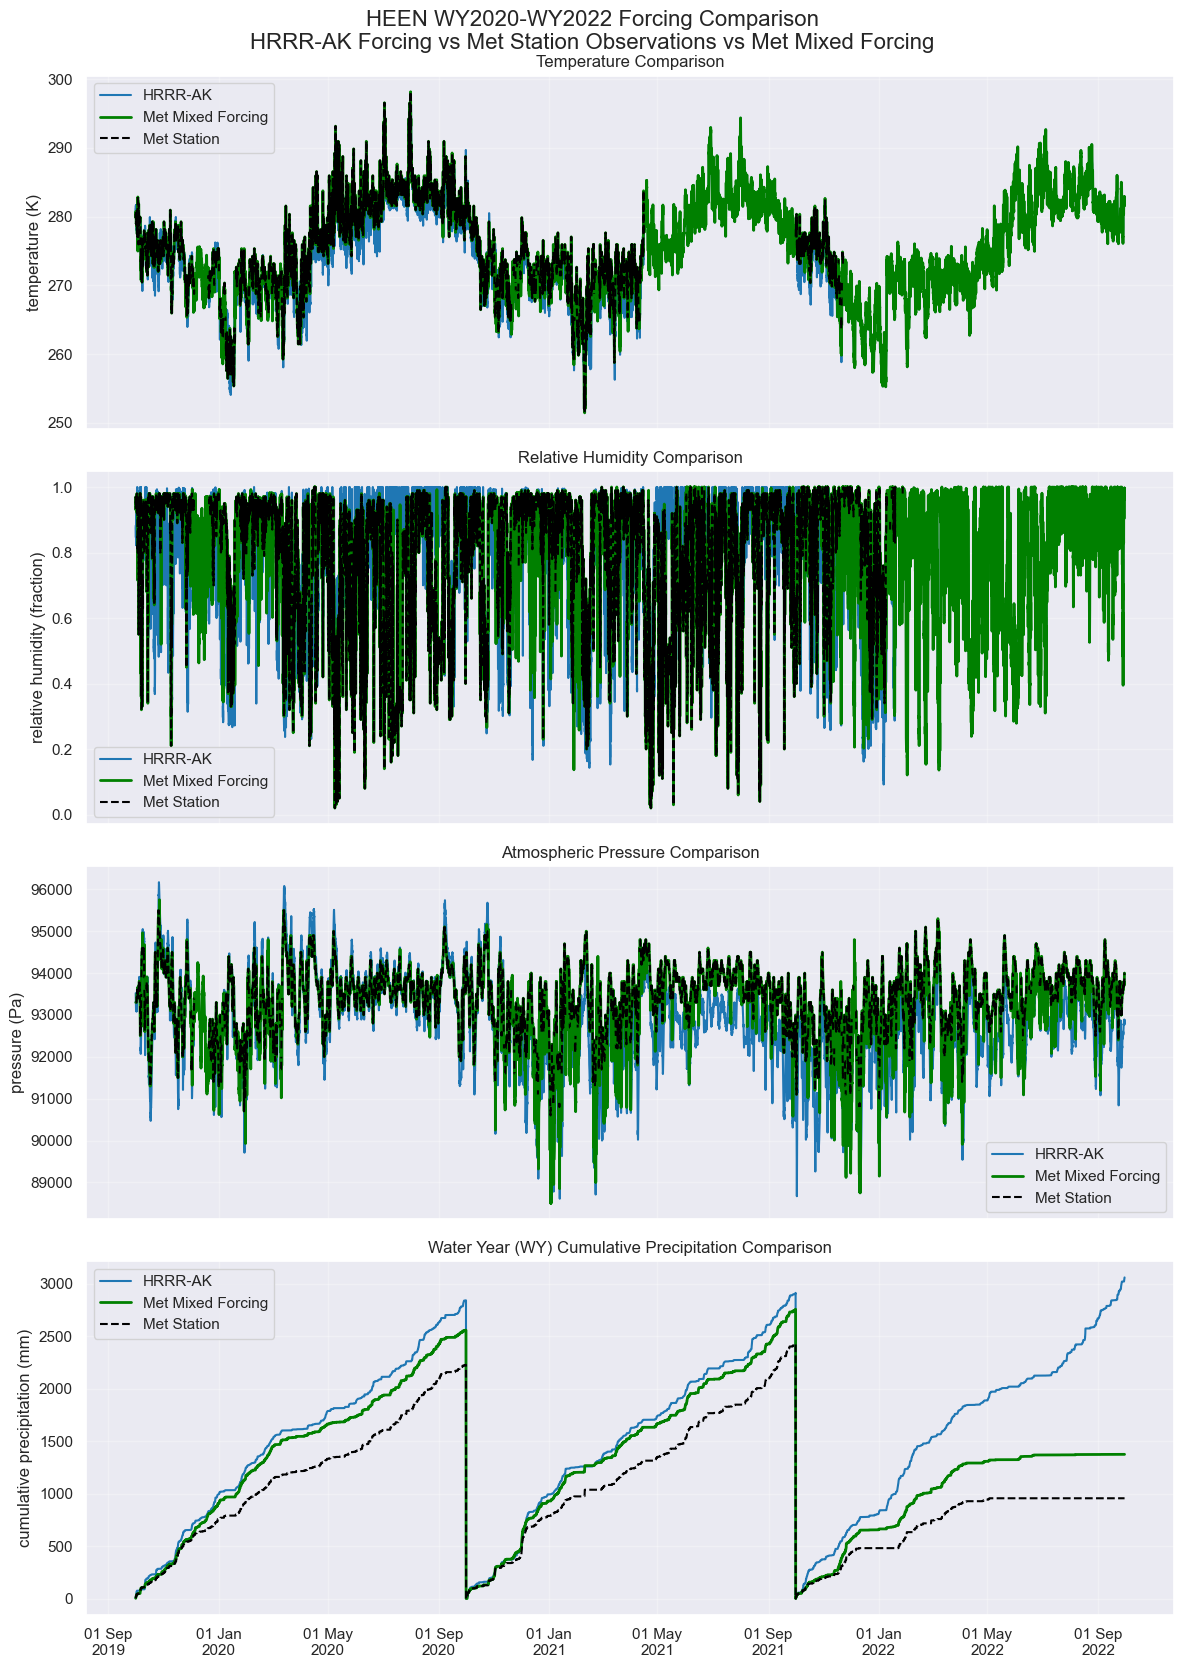

In [33]:
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter

# ============================================================
# MULTI-VARIABLE COMPARISON PLOT
# ============================================================

fig, axes = plt.subplots(
    4,
    1,
    figsize=(12, 17),
    sharex=True
)

# ============================================================
# TEMPERATURE
# ============================================================

ax = axes[0]

# All datasets already aligned and in Kelvin

ax.plot(
    ds_hrrrak["temp"].to_series(),
    label="HRRR-AK",
    color="tab:blue"
)

ax.plot(
    ds_filled["TA"].to_series(),
    label="Met Mixed Forcing",
    color="green",
    linewidth=2
)

ax.plot(
    ds_met["temp"].to_series(),
    label="Met Station",
    color="black",
    linestyle="--",
    
)

ax.set_ylabel("temperature (K)")
ax.set_title("Temperature Comparison")

ax.grid(alpha=0.3)
ax.legend()

# ============================================================
# RELATIVE HUMIDITY
# ============================================================

ax = axes[1]

# RH already converted to fraction [0-1]

ax.plot(
    ds_hrrrak["rh"].to_series(),
    label="HRRR-AK",
    color="tab:blue"
)

ax.plot(
    ds_filled["RH"].to_series(),
    label="Met Mixed Forcing",
    color="green",
    linewidth=2
)

ax.plot(
    ds_met["rh"].to_series(),
    label="Met Station",
    color="black",
    linestyle="--",
)

ax.set_ylabel("relative humidity (fraction)")
ax.set_title("Relative Humidity Comparison")

ax.grid(alpha=0.3)
ax.legend()

# ============================================================
# PRESSURE
# ============================================================

ax = axes[2]

ax.plot(
    ds_hrrrak["pressure"].to_series(),
    label="HRRR-AK",
    color="tab:blue"
)

ax.plot(
    ds_filled["PS"].to_series(),
    label="Met Mixed Forcing",
    color="green",
    linewidth=2
)

ax.plot(
    ds_met["pressure"].to_series(),
    label="Met Station",
    color="black",
    linestyle="--",
)

ax.set_ylabel("pressure (Pa)")
ax.set_title("Atmospheric Pressure Comparison")

ax.grid(alpha=0.3)
ax.legend()

# ============================================================
# PRECIPITATION
# ============================================================

ax = axes[3]

def wateryear_cumsum(da, wy_start_month=10):
    """
    Cumulative sum that resets at the start of each water year.
    Water year starts on Oct 1 by default.
    """
    s = da.fillna(0).to_series()

    # Water year label: Oct-Dec belong to next calendar year
    wy = s.index.year + (s.index.month >= wy_start_month)

    return s.groupby(wy).cumsum()


ax.plot(
    wateryear_cumsum(ds_hrrrak["precip_accum_1hr"]),
    label="HRRR-AK",
    color="tab:blue"
)

ax.plot(
    wateryear_cumsum(ds_filled["PSUM"]),
    label="Met Mixed Forcing",
    color="green",
    linewidth=2,
)

ax.plot(
    wateryear_cumsum(ds_met["precip_accum_1hr"]),
    label="Met Station",
    color="black",
    linestyle="--",
)

ax.set_ylabel("cumulative precipitation (mm)")
ax.set_title("Water Year (WY) Cumulative Precipitation Comparison")

ax.grid(alpha=0.3)
ax.legend()

# ============================================================
# COMMON X-AXIS
# ============================================================

def custom_date_formatter(x, pos):
    dt = mdates.num2date(x)
    return dt.strftime("%d %b\n%Y")

axes[-1].xaxis.set_major_formatter(
    FuncFormatter(custom_date_formatter)
)

axes[-1].set_xlabel("")

plt.suptitle(
    "HEEN WY2020-WY2022 Forcing Comparison\n"
    "HRRR-AK Forcing vs Met Station Observations vs Met Mixed Forcing",
    fontsize=16
)

plt.tight_layout()

plt.show()